In [4]:
import pandas as pd
import numpy as np
import random
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.environ import SolverFactory
import yfinance as yf
import matplotlib.pyplot as plt

## MODELO DE OTIMIZAÇÂO ROBUSTA em DUAS ETAPAS / Hierarquica



In [5]:
df_ativos=pd.read_csv(r'C:\Users\joaon\OneDrive\Documentos\GitHub\mestrado\base_dados\retornos_ativos2.csv').set_index(['Date'])
df_ibov=pd.read_csv(r'C:\Users\joaon\OneDrive\Documentos\GitHub\mestrado\base_dados\retorno_ibov2.csv').set_index(['Date']).dropna()

###  a ideia é, df de 12 meses, 2 meses finais para projecao
### sobram 10 meses, 5 para primeira otimização, 5 para a segunda

In [6]:
print("tamanho INICIAL df_ativo: ",df_ativos.shape)
print("tamanho INICIAL df_ibov: ",df_ibov.shape)

limite_20 = np.int32(len(df_ativos)*0.20)
resultado_80 = np.int32(len(df_ativos)) - limite_20

df_trabalho_ativo = df_ativos[0:resultado_80]
print("df de trabalho Ativo no tamanho de: ", len(df_trabalho_ativo))
df_trabalho_ibov = df_ibov[0:resultado_80]
print("df de trabalho IBOV no tamanho de: ", len(df_trabalho_ativo))

df_projecao_final_ibov = df_ibov[len(df_trabalho_ibov):]
print("df_projecao_final_ibov no tamanho de: ", len(df_projecao_final_ibov))
df_projecao_final_ativo = df_ativos[len(df_trabalho_ativo):]
print("df_projecao_final no tamanho de: ", len(df_projecao_final_ativo))

metade = np.int32(len(df_trabalho_ativo)/2)




tamanho INICIAL df_ativo:  (248, 85)
tamanho INICIAL df_ibov:  (248, 1)
df de trabalho Ativo no tamanho de:  199
df de trabalho IBOV no tamanho de:  199
df_projecao_final_ibov no tamanho de:  49
df_projecao_final no tamanho de:  49


In [7]:
# limite = np.int32(len(df_ativos) / 5 * 4)

retornos_ativo_treino = df_trabalho_ativo[0:metade]
# retornos_ativo_projecao = df_ativos[limite_60:]
retornos_ibov_treino = df_trabalho_ibov[0:metade]
# retornos_ibov_projecao = df_ibov[limite_60:]
print("Shape Ativo Treino: ",retornos_ativo_treino.shape)
# print("Shape Ativo Projeção: ",retornos_ativo_projecao_1.shape)
print("Shape Ativo Treino: ",retornos_ibov_treino.shape)
# print("Shape Ativo Projeção: ",retornos_ibov_projecao_1.shape)


#------------ PARA SEGUNDA ETAPA

retornos_ativo_segunda_etapa = df_trabalho_ativo[metade:]
retornos_ibov_segunda_etapa = df_trabalho_ibov[metade:]

print('-----------')
print("Shape Ativo 2º Treino: ",retornos_ativo_segunda_etapa.shape)
print("Shape Ibov 2º Treino: ",retornos_ibov_segunda_etapa.shape)


Shape Ativo Treino:  (99, 85)
Shape Ativo Treino:  (99, 1)
-----------
Shape Ativo 2º Treino:  (100, 85)
Shape Ibov 2º Treino:  (100, 1)


In [8]:
retornos_ativo_treino.fillna(0, inplace=True)

C:\Users\joaon\AppData\Local\Temp\ipykernel_17764\882124678.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  retornos_ativo_treino.fillna(0, inplace=True)


In [9]:
dicio_ativos = {}
for t in range(len(retornos_ativo_treino)):
    for a in range(len(retornos_ativo_treino.columns)):
        dicio_ativos[t,a] = retornos_ativo_treino.iloc[t,a]

dicio_ibov = {}
for t in range(len(retornos_ibov_treino)):
    dicio_ibov[t] = retornos_ibov_treino['IBOV'].iloc[t]



In [10]:
std_ativos = retornos_ativo_treino.std()
std_ativos = pd.DataFrame(std_ativos, columns=['desvio_padrao'])
dicio_std = {}
for a in range(len(retornos_ativo_treino.columns)):
    dicio_std[a] = std_ativos['desvio_padrao'].iloc[a]


## INICIAR MODELO

In [11]:
model = pyo.ConcreteModel()

# RANGE SET
model.A = pyo.RangeSet(0,len(retornos_ativo_treino.columns)-1)
model.T = pyo.RangeSet(0, len(retornos_ativo_treino)-1)

# PARAMETROS----------------------
model.ATIVOS = pyo.Param(model.T,model.A, initialize=dicio_ativos)
model.IBOV = pyo.Param(model.T, initialize=dicio_ibov)
model.DELTA = pyo.Param(model.A, initialize = dicio_std)
    ##----------------- GAMA: Orçamento de Incerteza -> Defini quantos ativos podem variar ao mesmo tempo (Seguro geral)
        ##  ------ mutable = True -> define parâmetros que podem ser alterados entre execuções de otimização sem reconstruir o modelo
            ##----model.GAMA = 2.0  # Forma simples  OU model.GAMA.store(2.0)
model.GAMA = pyo.Param(initialize = 5.0, mutable = True)
model.QUANTIDADE_ATIVOS = pyo.Param(initialize = 25.0)

# VARIAVEIS----------------------
model.x = pyo.Var(model.A, bounds=(0,1))
model.y = pyo.Var(model.A, within=pyo.Binary)
    ## Para cada dia $t$, o modelo precisa de variáveis extras para "absorver" a incerteza: z[t]: Uma variável global de proteção para o dia $t$. p[t, a]: Uma variável de proteção específica para cada ativo no dia $t$.
model.z = pyo.Var(model.T, bounds=(0,None))
model.p = pyo.Var(model.T, model.A, bounds=(0,None))

    #Capturar erro absoluto de cada dia
model.erro = pyo.Var(model.T, bounds=(0,None))

##------------ ALTERAÇÂO DE MSE para MAD 
def erro_pos(model, t):
    return model.erro[t] >= sum(model.ATIVOS[t,a] * model.x[a] for a in model.A) - model.IBOV[t]
def erro_neg(model, t):
    return model.erro[t] >= -(sum(model.ATIVOS[t,a] * model.x[a] for a in model.A) - model.IBOV[t])

model.con_erro_post = pyo.Constraint(model.T, rule=erro_pos)
model.con_erro_neg = pyo.Constraint(model.T, rule=erro_neg)
# controle_peso_da_protecao = 0.1
controle_peso_da_protecao = 1

# OBJETIVO----------------------
def func_objetivo_1(model):
    mad = sum(model.erro[t] for t in model.T)
    
    ## Termo de proteção Robusta -----------
    protecao = sum(
        (model.GAMA * model.z[t] + sum(model.p[t,a] for a in model.A)) for t in model.T
    )

    

    return mad + controle_peso_da_protecao*protecao

model.obj = pyo.Objective(rule=func_objetivo_1,sense=pyo.minimize)



In [12]:
# RESTRICOES ----------------------
    ## - Ela diz que a proteção deve ser maior ou igual ao impacto do desvio padrão no peso do ativo
def regra_protecao(model,t,a):
    
    return model.z[t] + model.p[t,a] <= model.DELTA[a] * model.x[a]

model.con_protecao = pyo.Constraint(model.T,model.A, rule=regra_protecao)

    ## OUTRAS RESTRIÇÔES

    # 1- Cardinalidade (total ativos na carteira)
def cardinalidade(model):

    return sum(
        model.y[a] for a in model.A
    ) <= model.QUANTIDADE_ATIVOS
model.cardinalidade = pyo.Constraint(rule=cardinalidade)

    # 2 - Soma peso da carteira
def soma_peso_1(model):
    return sum(model.x[a] for a in model.A) == 1
model.soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

    # 3 - x só ativa se y=1
def restr_vinculo_x_y(model, a):

    return model.x[a] <= model.y[a]

model.restr_vinculo_x_y = pyo.Constraint(model.A, rule=restr_vinculo_x_y)

    # Retrição de Peso mínimo, se y=1, x deve ser pelo menos 1%
def peso_min(model, a):
    return model.x[a] >= 0.01 * model.y[a]
model.peso_min = pyo.Constraint(model.A, rule=peso_min)




In [13]:
# Antes do solve, dê uma solução inicial ao CPLEX
for a in model.A:
    model.x[a].value = 1/25  # Peso igual para 20 ativos
    model.y[a].value = 1 if a < 25 else 0

In [14]:
opt = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
opt.options['TimeLimit'] = 180 
# resultado = opt.solve(model)
# opt.options['optimalitytarget'] = 3 ## PARA CASO DE MODELOS NAO LINEARES
# opt.options['mip tolerances absmipgap'] = 0.01 
# opt.options['mip tolerances mipgap'] = 0.01 
# opt.options['mipgap'] = 0.01 

results = opt.solve(model, tee=True, warmstart=True)
print("-------FIM----------")



Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmpgzav6k_g.cplex.log' open.
CPLEX> New value for time limit in seconds: 180
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmpygvf9fbv.pyomo.lp' read.
Read time = 0.02 sec. (1.15 ticks)
CPLEX> MIP start file 'C:\Users\joaon\AppData\Local\Temp\tmpfyqyumcz.cplex.mst' read.
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmpygvf9fbv.pyomo.lp
Objective sense      : Minimize
Variables            :    8783  [Nneg: 8613,  Box: 85,  Binary: 85]
Objective nonzeros   :    8613
Linear constraints   :    8785  [Less: 8784,  Equal: 1]
  Nonzeros        

           peso_ativo  ativado
VALE3.SA     0.130868      1.0
ITUB4.SA     0.094268      1.0
PETR4.SA     0.119784      1.0
AXIA3.SA     0.067473      1.0
SBSP3.SA     0.043940      1.0
B3SA3.SA     0.026749      1.0
BPAC11.SA    0.021296      1.0
WEGE3.SA     0.027080      1.0
BBAS3.SA     0.057688      1.0
ABEV3.SA     0.018439      1.0
RENT3.SA     0.030502      1.0
VBBR3.SA     0.015904      1.0
RADL3.SA     0.016025      1.0
BBDC3.SA     0.057913      1.0
GGBR4.SA     0.026285      1.0
CMIG4.SA     0.038495      1.0
TIMS3.SA     0.026479      1.0
TOTS3.SA     0.027502      1.0
BBSE3.SA     0.026525      1.0
ENGI11.SA    0.051837      1.0
MBRF3.SA     0.011737      1.0
DIRR3.SA     0.029059      1.0
YDUQ3.SA     0.010000      1.0
RECV3.SA     0.010000      1.0
HAPV3.SA     0.014152      1.0
107.15035898514684
110.65096464275084
106.3946658199716


C:\Users\joaon\AppData\Local\Temp\ipykernel_17764\3236620284.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_otimizado[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_17764\3236620284.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_equi[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_17764\3236620284.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(acum_ibov[-1])


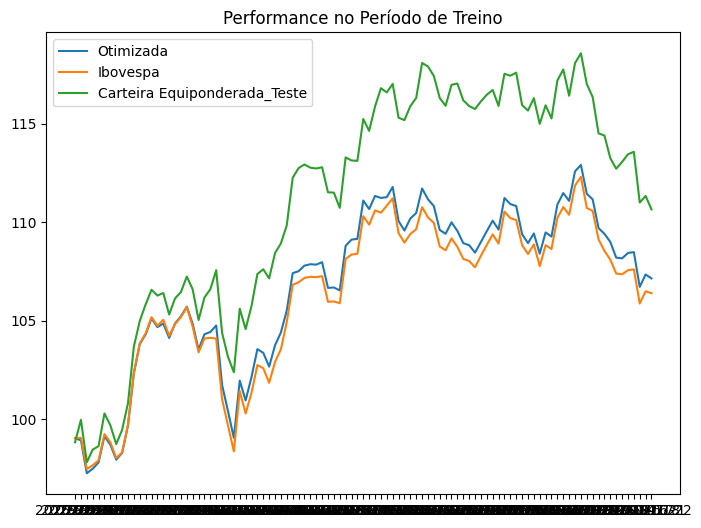

In [15]:
lsita_grande = []
for numero in range(len(retornos_ativo_treino.columns)):
    peso_ativo = pyo.value(model.x[numero])
    ativado = pyo.value(model.y[numero])
    lista = [peso_ativo, ativado]
    lsita_grande.append(lista)
    
final = pd.DataFrame(lsita_grande, columns=["peso_ativo","ativado"], index=retornos_ativo_treino.columns)
print(final[final['ativado']==1])
df_final = final[final['ativado']==1]
ativos_selecionados = df_final.index
retornos_carteira= retornos_ativo_treino[ativos_selecionados]


carteira_otimizada = (retornos_carteira*df_final['peso_ativo']).sum(axis=1)
carteira_otimizada = 1 + carteira_otimizada

carteira_equi = retornos_carteira.mean(axis=1)
carteira_equi = 1 + carteira_equi

# 3. Transformar em Retorno Acumulado (Base 100)
acum_otimizado = (carteira_otimizada).cumprod() * 100
acum_equi = (carteira_equi).cumprod() * 100
acum_ibov = (1 + retornos_ibov_treino['IBOV']).cumprod() * 100

print(acum_otimizado[-1])
print(acum_equi[-1])
print(acum_ibov[-1])

qnt_carteira = pyo.value(model.QUANTIDADE_ATIVOS)
texto = f'Comparação de Performance: Index Tracking ({qnt_carteira} ativos)'

plt.figure(figsize=(18, 6))


# Gráfico 1: Período de Treino
plt.subplot(1, 2, 1)
plt.plot(acum_otimizado, label="Otimizada")
plt.plot(acum_ibov, label="Ibovespa")
plt.plot(acum_equi, label="Carteira Equiponderada_Teste")
plt.title("Performance no Período de Treino")
plt.legend()



plt.show()

### ----------------------------

## CONSTRUÇÃO DA SEGUNDA ETAPA

### ----------------------------

In [16]:
dicio_ativos_segunda_etapa = {}
retornos_ativo_segunda_etapa = retornos_ativo_segunda_etapa[df_final.index]
for t in range(len(retornos_ativo_segunda_etapa)):
    for a in range(len(retornos_ativo_segunda_etapa.columns)):
        dicio_ativos_segunda_etapa[t,a] = retornos_ativo_segunda_etapa.iloc[t,a]

dicio_ibov_segunda_etapa = {}
for t in range(len(retornos_ibov_segunda_etapa)):
    dicio_ibov_segunda_etapa[t] = retornos_ibov_segunda_etapa['IBOV'].iloc[t]


std_ativos_segunda_etapa = retornos_ativo_segunda_etapa.std()
std_ativos_segunda_etapa = pd.DataFrame(std_ativos_segunda_etapa, columns=['desvio_padrao'])
dicio_std_segunda_etapa = {}
for a in range(len(retornos_ativo_segunda_etapa.columns)):
    dicio_std_segunda_etapa[a] = std_ativos_segunda_etapa['desvio_padrao'].iloc[a]


#### ----- Iniciando segundo modelo

In [ ]:
model_2 = pyo.ConcreteModel()

# RANGE SET
model_2.A = pyo.RangeSet(0,len(retornos_ativo_segunda_etapa.columns)-1)
model_2.T = pyo.RangeSet(0, len(retornos_ativo_segunda_etapa)-1)

# PARAMETROS----------------------
model_2.ATIVOS = pyo.Param(model_2.T,model_2.A, initialize=dicio_ativos_segunda_etapa)
model_2.IBOV = pyo.Param(model_2.T, initialize=dicio_ibov_segunda_etapa)
model_2.DELTA = pyo.Param(model_2.A, initialize = dicio_std_segunda_etapa)
    ##----------------- GAMA: Orçamento de Incerteza -> Defini quantos ativos podem variar ao mesmo tempo (Seguro geral)
        ##  ------ mutable = True -> define parâmetros que podem ser alterados entre execuções de otimização sem reconstruir o modelo
            ##----model.GAMA = 2.0  # Forma simples  OU model.GAMA.store(2.0)
model_2.GAMA = pyo.Param(initialize = 5.0, mutable = True)
model_2.QUANTIDADE_ATIVOS = pyo.Param(initialize = 10.0)

# VARIAVEIS----------------------
model_2.x = pyo.Var(model_2.A, bounds=(0,1))
model_2.y = pyo.Var(model_2.A, within=pyo.Binary)
    ## Para cada dia $t$, o modelo precisa de variáveis extras para "absorver" a incerteza: z[t]: Uma variável global de proteção para o dia $t$. p[t, a]: Uma variável de proteção específica para cada ativo no dia $t$.
model_2.z = pyo.Var(model_2.T, bounds=(0,None))
model_2.p = pyo.Var(model_2.T, model_2.A, bounds=(0,None))

    #Capturar erro absoluto de cada dia
model_2.erro = pyo.Var(model_2.T, bounds=(0,None))

##------------ ALTERAÇÂO DE MSE para MAD 
def erro_pos(model_2, t):
    return model_2.erro[t] >= sum(model_2.ATIVOS[t,a] * model_2.x[a] for a in model_2.A) - model_2.IBOV[t]
def erro_neg(model_2, t):
    return model_2.erro[t] >= -(sum(model_2.ATIVOS[t,a] * model_2.x[a] for a in model_2.A) - model_2.IBOV[t])

model_2.con_erro_post = pyo.Constraint(model_2.T, rule=erro_pos)
model_2.con_erro_neg = pyo.Constraint(model_2.T, rule=erro_neg)
controle_peso_da_protecao = 0.1
# controle_peso_da_protecao = 1

# OBJETIVO----------------------
def func_objetivo_1(model_2):
    mad = sum(model_2.erro[t] for t in model_2.T)
    
    ## Termo de proteção Robusta -----------
    protecao = sum(
        (model_2.GAMA * model_2.z[t] + sum(model_2.p[t,a] for a in model_2.A)) for t in model_2.T
    )

    

    return mad + controle_peso_da_protecao*protecao

model_2.obj = pyo.Objective(rule=func_objetivo_1,sense=pyo.minimize)


# RESTRICOES ----------------------
    ## - Ela diz que a proteção deve ser maior ou igual ao impacto do desvio padrão no peso do ativo
def regra_protecao(model_2,t,a):
    
    return model_2.z[t] + model_2.p[t,a] <= model_2.DELTA[a] * model_2.x[a]

model_2.con_protecao = pyo.Constraint(model_2.T,model_2.A, rule=regra_protecao)

    ## OUTRAS RESTRIÇÔES

    # 1- Cardinalidade (total ativos na carteira)
def cardinalidade(model_2):

    return sum(
        model_2.y[a] for a in model_2.A
    ) <= model_2.QUANTIDADE_ATIVOS
model_2.cardinalidade = pyo.Constraint(rule=cardinalidade)

    # 2 - Soma peso da carteira
def soma_peso_1(model_2):
    return sum(model_2.x[a] for a in model_2.A) == 1
model_2.soma_peso_1 = pyo.Constraint(rule=soma_peso_1)

    # 3 - x só ativa se y=1
def restr_vinculo_x_y(model_2, a):

    return model_2.x[a] <= model_2.y[a]

model_2.restr_vinculo_x_y = pyo.Constraint(model_2.A, rule=restr_vinculo_x_y)

    # Retrição de Peso mínimo, se y=1, x deve ser pelo menos 1%
def peso_min(model_2, a):
    return model_2.x[a] >= 0.01 * model_2.y[a]
model_2.peso_min = pyo.Constraint(model_2.A, rule=peso_min)




In [26]:
# Antes do solve, dê uma solução inicial ao CPLEX
for a in model_2.A:
    model_2.x[a].value = pyo.value(model.x[a])  # Peso igual para 20 ativos
    model_2.y[a].value = pyo.value(model.y[a])

In [28]:
opt2 = SolverFactory('cplex', executable='C:\\CPLEX_Studio2211\\cplex\\bin\\x64_win64\\cplex.exe')
opt2.options['TimeLimit'] = 180 
# resultado = opt.solve(model)
# opt.options['optimalitytarget'] = 3 ## PARA CASO DE MODELOS NAO LINEARES
# opt2.options['mip tolerances absmipgap'] = 0.01 
# opt2.options['mip tolerances mipgap'] = 0.01 
# opt2.options['mipgap'] = 0.01 

results = opt2.solve(model_2, tee=True, warmstart=True)
print("-------FIM----------")



Welcome to IBM(R) ILOG(R) CPLEX(R) Interactive Optimizer 22.1.1.0
  with Simplex, Mixed Integer & Barrier Optimizers
5725-A06 5725-A29 5724-Y48 5724-Y49 5724-Y54 5724-Y55 5655-Y21
Copyright IBM Corp. 1988, 2022.  All Rights Reserved.

Type 'help' for a list of available commands.
Type 'help' followed by a command name for more
information on commands.

CPLEX> Logfile 'cplex.log' closed.
Logfile 'C:\Users\joaon\AppData\Local\Temp\tmp2p_won5g.cplex.log' open.
CPLEX> New value for time limit in seconds: 180
CPLEX> Problem 'C:\Users\joaon\AppData\Local\Temp\tmpy3dknhur.pyomo.lp' read.
Read time = 0.00 sec. (0.34 ticks)
CPLEX> MIP start file 'C:\Users\joaon\AppData\Local\Temp\tmprf9jffzy.cplex.mst' read.
CPLEX> Problem name         : C:\Users\joaon\AppData\Local\Temp\tmpy3dknhur.pyomo.lp
Objective sense      : Minimize
Variables            :    2750  [Nneg: 2700,  Box: 25,  Binary: 25]
Objective nonzeros   :    2700
Linear constraints   :    2752  [Less: 2751,  Equal: 1]
  Nonzeros        

## SEGUNDO GRAFICO

In [29]:
lsita_grande_2 = []
for numero in range(len(retornos_ativo_segunda_etapa.columns)):
    peso_ativo = pyo.value(model_2.x[numero])
    ativado = pyo.value(model_2.y[numero])
    lista = [peso_ativo, ativado]
    lsita_grande_2.append(lista)
    
final_2 = pd.DataFrame(lsita_grande_2, columns=["peso_ativo","ativado"], index=retornos_ativo_segunda_etapa.columns)
# print(final_2[final_2['ativado']==1])
df_final_2 = final_2[final_2['ativado']==1]

print(df_final_2)
ativos_selecionados = df_final_2.index

           peso_ativo  ativado
VALE3.SA     0.183274      1.0
ITUB4.SA     0.112168      1.0
PETR4.SA     0.176232      1.0
SBSP3.SA     0.064997      1.0
B3SA3.SA     0.102354      1.0
BBAS3.SA     0.046086      1.0
RADL3.SA     0.024143      1.0
BBDC3.SA     0.081809      1.0
BBSE3.SA     0.072279      1.0
ENGI11.SA    0.136659      1.0


In [30]:
carteira_otimizada_1 = (df_projecao_final_ativo[df_final.index]*df_final['peso_ativo']).sum(axis=1)
acum_otimizado_1 = (1+carteira_otimizada_1).cumprod()*100
carteira_otimizada_2 = (df_projecao_final_ativo[df_final_2.index]*df_final_2['peso_ativo']).sum(axis=1)
acum_otimizado_2 = (1+carteira_otimizada_2).cumprod()*100

#ibov
valor_ibov_1 = df_projecao_final_ibov
acum_ibov_1 = (1+valor_ibov_1).cumprod()*100

C:\Users\joaon\AppData\Local\Temp\ipykernel_17764\360219905.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Carteira 1: ",acumulado_final_carteira_1[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_17764\360219905.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Carteira 2: ",acumulado_final_carteira_2[-1])
C:\Users\joaon\AppData\Local\Temp\ipykernel_17764\360219905.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc

Carteira 1:  152.77187321032545
Carteira 2:  154.76898682026354
Ibovespa:  151.8082235275447


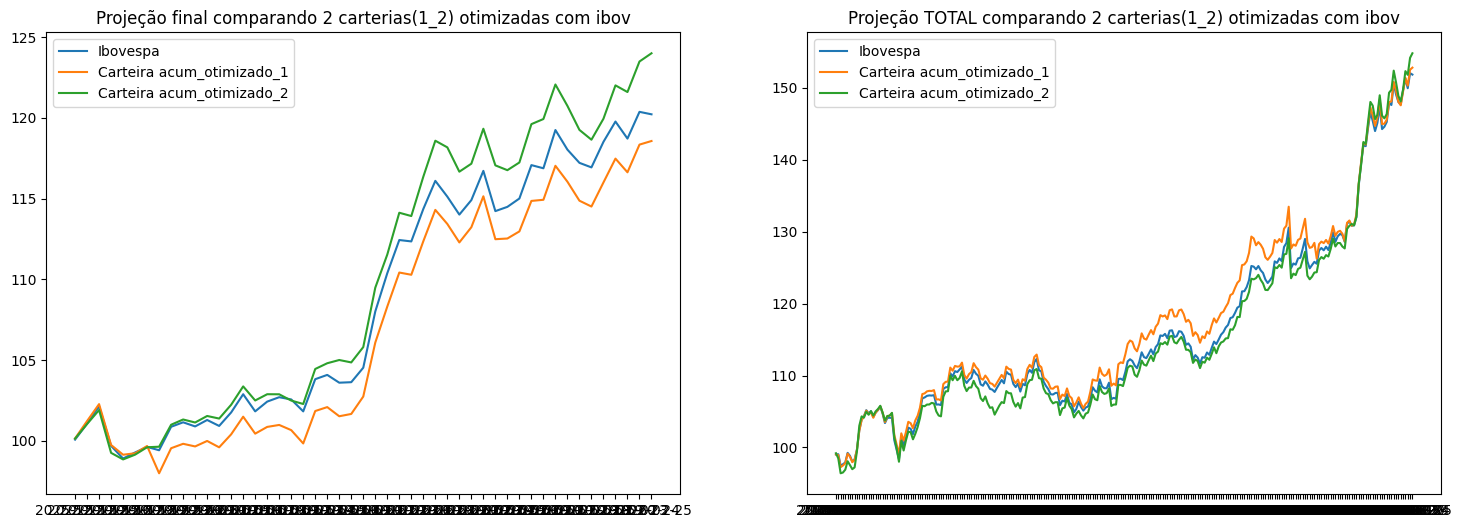

In [31]:

qnt_carteira = pyo.value(model_2.QUANTIDADE_ATIVOS)
texto = f'Comparação de Performance: Index Tracking ({qnt_carteira} ativos)'

plt.figure(figsize=(18, 6))


#Qual graficos eu quero?
# quero comparar o resultado da otimização_2 com a 1 e o ibov
acum_ibov = df_projecao_final_ibov


# Gráfico 1: Período de Treino
plt.subplot(1, 2, 1)
plt.plot(acum_ibov_1, label="Ibovespa")
plt.plot(acum_otimizado_1, label="Carteira acum_otimizado_1")
plt.plot(acum_otimizado_2, label="Carteira acum_otimizado_2")
plt.title("Projeção final comparando 2 carterias(1_2) otimizadas com ibov")
plt.legend()


# ---------- GRAFICO 2

final_carteira_1 = (df_ativos[df_final.index]*df_final['peso_ativo']).sum(axis=1)
acumulado_final_carteira_1 = (1+final_carteira_1).cumprod()*100

final_carteira_2 = (df_ativos[df_final_2.index]*df_final_2['peso_ativo']).sum(axis=1)
acumulado_final_carteira_2 = (1+final_carteira_2).cumprod()*100

final_ibov_2 = df_ibov['IBOV']
acumulado_ibov_2 = (1+final_ibov_2).cumprod()*100

print("Carteira 1: ",acumulado_final_carteira_1[-1])
print("Carteira 2: ",acumulado_final_carteira_2[-1])
# print(acum_equi[-1])
print("Ibovespa: ",acumulado_ibov_2[-1])

plt.subplot(1, 2, 2)
plt.plot(acumulado_ibov_2, label="Ibovespa")
plt.plot(acumulado_final_carteira_1, label="Carteira acum_otimizado_1")
plt.plot(acumulado_final_carteira_2, label="Carteira acum_otimizado_2")
plt.title("Projeção TOTAL comparando 2 carterias(1_2) otimizadas com ibov")
plt.legend()

plt.show()

In [33]:
model_2.pprint()

2 RangeSet Declarations
    A : Dimen=1, Size=25, Bounds=(0, 24)
        Key  : Finite : Members
        None :   True :  [0:24]
    T : Dimen=1, Size=100, Bounds=(0, 99)
        Key  : Finite : Members
        None :   True :  [0:99]

5 Param Declarations
    ATIVOS : Size=2500, Index=T*A, Domain=Any, Default=None, Mutable=False
        Key      : Value
          (0, 0) : -0.0013913279503715
          (0, 1) :  0.0111430268312238
          (0, 2) :  0.0204146001795533
          (0, 3) :  0.0036231208068773
          (0, 4) :  0.0077209798044517
          (0, 5) :  0.0244836395520817
          (0, 6) :  0.0178931645799704
          (0, 7) : -0.0801065908200844
          (0, 8) :  0.0160885697517703
          (0, 9) :  0.0141791435487137
         (0, 10) :  0.0120112523295803
         (0, 11) :  0.0110054742184164
         (0, 12) :  0.0092592508237028
         (0, 13) :  0.0164057351311854
         (0, 14) :  0.0183323194902915
         (0, 15) :  0.0222221358079359
         (0, 16) : 